In [ ]:
import torch
print("CUDA:", torch.cuda.is_available())


CUDA: True


In [ ]:
import os
os.listdir()

['.config',
 'filtered_dataset_full.csv',
 'filtered_dataset_clean.csv',
 'viz_emotion_dataset_with_image_paths.pkl',
 'sample_data']

In [ ]:
import pickle
path = 'viz_emotion_dataset_with_image_paths.pkl'

with open(path, 'rb') as f:
    data = pickle.load(f)

type(data)

pandas.core.frame.DataFrame

In [ ]:
data.head()

,id,text,title,dashboard_id,sentiment,ai_sentiment,sentiment_is_userfilled,index,img_path,date,tags,ai_tags,tags_is_userfilled,type,query_name,image_path
0,3622403824480912881,#ad Το να επιλέγεις τοπ γεύση δεν σε κάνει κάπ...,,1694,1,,True,instagram__media_20251020,,NaT,,,,,,second_scrapping_instagram/3622403824480912881...
1,3622788220579854754,"#ad 🔥 When Flamin’ Hot hits, even the gods can...",,1704,1,,True,instagram__media_20251020,,NaT,,,,,,second_scrapping_instagram/3622788220579854754...
2,3623011555533388168,❗ΤΕΛΕΥΤΑΙΕΣ ΕΜΦΑΝΙΣΕΙΣ❗ Το Reun''90s Live Part...,,953,0,,True,instagram__media_20251020,,NaT,,,,,,second_scrapping_instagram/3623011555533388168...
3,3623405654475275223,"#START \nΠΑΡΑΣΚΕΥΗ 02/05, στις 20:00, στην #Ε...",,1765,0,,True,instagram__media_20251020,,NaT,,,,,,second_scrapping_instagram/3623405654475275223...
4,3623482624140772285,Athens Street Food Festival + Coca-Cola = Διπλ...,,1700,1,,True,instagram__media_20251020,/content/drive/MyDrive/Images_thesis/scrapping...,NaT,,,,,,/content/drive/MyDrive/Images_thesis/scrapping...


In [ ]:
data.columns

Index(['id', 'text', 'title', 'dashboard_id', 'sentiment', 'ai_sentiment',
       'sentiment_is_userfilled', 'index', 'img_path', 'date', 'tags',
       'ai_tags', 'tags_is_userfilled', 'type', 'query_name', 'image_path'],
      dtype='object')

In [ ]:
data.shape

(11191, 16)

In [ ]:
data['image_path'].head()

,image_path
0,second_scrapping_instagram/3622403824480912881...
1,second_scrapping_instagram/3622788220579854754...
2,second_scrapping_instagram/3623011555533388168...
3,second_scrapping_instagram/3623405654475275223...
4,/content/drive/MyDrive/Images_thesis/scrapping...


In [ ]:
###excel####

import pandas as pd

df_excel = pd.read_csv("filtered_dataset_clean.csv")
df_excel.head()

,image_path,full_image_path,voted_expressed,voted_expressed_conf,voted_induced,voted_induced_conf,raw_response,quality_decision,quality_confidence,quality_reason
0,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Negative,83.75,Neutral,67.50,EXPRESSED_SENTIMENT: negative\nEXPRESSED_CONF...,KEEP,90,"The image contains a person and a setting, pro..."
1,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Neutral,81.25,Negative,77.50,EXPRESSED_SENTIMENT: neutral\nEXPRESSED_CONFI...,KEEP,95,The image contains faces with discernible expr...
2,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Positive,91.25,Positive,85.00,EXPRESSED_SENTIMENT: positive\nEXPRESSED_CONF...,KEEP,95,The image contains meaningful visual content (...
3,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Negative,74.50,Negative,73.25,EXPRESSED_SENTIMENT: Neutral\nEXPRESSED_CONFI...,KEEP,85,The image contains a photograph with text over...
4,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Negative,82.50,Negative,86.25,EXPRESSED_SENTIMENT: neutral\nEXPRESSED_CONFI...,KEEP,85,The image depicts a scene with potential emoti...


In [ ]:
df_excel.columns

Index(['image_path', 'full_image_path', 'voted_expressed',
       'voted_expressed_conf', 'voted_induced', 'voted_induced_conf',
       'raw_response', 'quality_decision', 'quality_confidence',
       'quality_reason'],
      dtype='object')

In [ ]:
df_excel.shape

(1881, 10)

In [ ]:
df_excel['quality_decision'].value_counts()

,count
quality_decision,
KEEP,1881


In [ ]:
import pandas as pd
###ξεκιναω μια eda###

df = data.copy()   #το pkl
df = df[~df['text'].isna()].copy()  # πετάω όσα δεν έχουν κείμενο
len(df)


11191

In [ ]:
###στατιστικά για μήκος κειμένου###

#Μήκος σε χαρακτήρες
df['char_len'] = df['text'].str.len()
print(df['char_len'].describe())

#Μήκος σε λέξεις
df['word_len'] = df['text'].str.split().apply(len)
print(df['word_len'].describe())

count    11191.000000
mean       409.512019
std        399.684680
min          1.000000
25%        135.000000
50%        282.000000
75%        539.000000
max       2204.000000
Name: char_len, dtype: float64
count    11191.000000
mean        58.271736
std         59.742311
min          1.000000
25%         18.000000
50%         38.000000
75%         76.000000
max        390.000000
Name: word_len, dtype: float64


Mean ≈ 410 χαρακτήρες και Mean = 58 λέξεις → τα posts είναι μεγάλα.

Std ≈ 400 χαρακτήρες και από 1 λέξη μέχρι 792→ τεράστια ποικιλία στο μήκος.

Χρειάζεται μοντέλο που αντέχει μεγάλα sequences:
XLM-R Base μπορεί ~512 tokens
XLM-R Large ή Longformer μπορεί περισσότερα.
LLMs τα χειρίζονται σίγουρα: Qwen / LLaMA υποστηρίζουν 4k–32k tokens

In [ ]:
###tokens###
from transformers import XLMRobertaTokenizerFast
tokenizer = XLMRobertaTokenizerFast.from_pretrained("xlm-roberta-base")

df["token_len"] = df["text"].astype(str).apply(lambda x: len(tokenizer(x)["input_ids"]))

df["token_len"].describe()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (568 > 512). Running this sequence through the model will result in indexing errors


,token_len
count,11191.000000
mean,130.604682
std,122.262191
min,3.000000
25%,46.500000
50%,93.000000
75%,171.000000
max,847.000000


In [ ]:
(df["token_len"] > 512).mean()

np.float64(0.021981949781074078)

Άρα, το 97.8% του dataset δουλεύει με XLM-R, ενώ μόνο το 2.2% των captions ξεπερνά το όριο των 512 tokens και θα χρειαστεί truncation.

Συνεπώς, μοντέλα τύπου BERT είναι κατάλληλα για expressed sentiment χωρίς να χάνεται νόημα. Το truncation στο 2% δεν επηρεάζει σοβαρά το performance.
Παρότι το 2.2% των captions υπερβαίνει το όριο των 512 tokens, δεν θα επιλέξουμε LLMs για το expressed sentiment. Η επιλογή LLM προτείνεται κυρίως για το induced sentiment λόγω της απαίτησης reasoning, όχι για λόγους μήκους input.

In [ ]:
###βιβλιοθήκες για emojis και γλώσσα###
!pip install emoji langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.5 MB/s eta 0:00:00
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=0870eedc3ecc4f6c83d6660b625c12585e95e384041d1739db473d2d75bc6492
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [ ]:
import emoji
import langid
import re

In [ ]:
###ποια κείμενα έχουν emojis και πόσα###
def has_emoji(s):
    if not isinstance(s, str):
        return False
    return any(ch in emoji.EMOJI_DATA for ch in s)

def count_emojis(s):
    if not isinstance(s, str):
        return 0
    return sum(ch in emoji.EMOJI_DATA for ch in s)

df['has_emoji'] = df['text'].apply(has_emoji)
df['emoji_count'] = df['text'].apply(count_emojis)

print(df['has_emoji'].value_counts())
print(df['has_emoji'].value_counts(normalize=True))  # ποσοστά
print(df['emoji_count'].describe())

has_emoji
True     7641
False    3550
Name: count, dtype: int64
has_emoji
True     0.682781
False    0.317219
Name: proportion, dtype: float64
count    11191.000000
mean         2.651595
std          3.809383
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         53.000000
Name: emoji_count, dtype: float64


In [ ]:
####κανω merge το excel με το pkl###
df_final = df_excel.merge(
    data[['image_path', 'text']],
    on='image_path',
    how='left'
)

In [ ]:
df_final.shape
df_final.head()

,image_path,full_image_path,voted_expressed,voted_expressed_conf,voted_induced,voted_induced_conf,raw_response,quality_decision,quality_confidence,quality_reason,text
0,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Negative,83.75,Neutral,67.50,EXPRESSED_SENTIMENT: negative\nEXPRESSED_CONF...,KEEP,90,"The image contains a person and a setting, pro...",Δικαιοσύνη ή οικογένεια;🤔 Τι θα διάλεγες αν ήσ...
1,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Neutral,81.25,Negative,77.50,EXPRESSED_SENTIMENT: neutral\nEXPRESSED_CONFI...,KEEP,95,The image contains faces with discernible expr...,Δεν προχώρησε τελικά... 👉 Το #5x5 με τον Θάνο ...
2,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Positive,91.25,Positive,85.00,EXPRESSED_SENTIMENT: positive\nEXPRESSED_CONF...,KEEP,95,The image contains meaningful visual content (...,Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! 💘...
3,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Negative,74.50,Negative,73.25,EXPRESSED_SENTIMENT: Neutral\nEXPRESSED_CONFI...,KEEP,85,The image contains a photograph with text over...,"🦠 Με συχνότητα εμφάνισης 3,4 στους 1.000 υγιεί..."
4,/content/drive/MyDrive/Images_thesis/data365/f...,/home/ir/Downloads/viz_sentiment_llm_kickstart...,Negative,82.50,Negative,86.25,EXPRESSED_SENTIMENT: neutral\nEXPRESSED_CONFI...,KEEP,85,The image depicts a scene with potential emoti...,Ουκρανία: Επιβεβαίωσε την επίθεση σε βάση ρωσι...


In [ ]:
df_final.shape

(1881, 11)

In [ ]:
###eda στο clean dataset###
###μηκος κειμενου

df_final["text_length"] = df_final["text"].astype(str).apply(len)
df_final["text_length"].describe()

,text_length
count,1881.000000
mean,466.167996
std,408.913504
min,1.000000
25%,170.000000
50%,348.000000
75%,618.000000
max,2200.000000


In [ ]:
###tokens final dataset###
!pip install transformers

from transformers import AutoTokenizer
import numpy as np

# tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# υπολογισμός tokens
df_final["token_len"] = df_final["text"].astype(str).apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

df_final["token_len"].describe()

Token indices sequence length is longer than the specified maximum sequence length for this model (556 > 512). Running this sequence through the model will result in indexing errors


,token_len
count,1881.000000
mean,146.780436
std,124.444032
min,4.000000
25%,58.000000
50%,111.000000
75%,189.000000
max,847.000000


In [ ]:
(df_final["token_len"] > 512).mean()

np.float64(0.02658160552897395)

Κατανομή Πλήθους Λέξεων ανά Post - γράφημα

In [ ]:
# πλήθος λέξεων ανά post
df_final["word_len"] = df_final["text"].astype(str).str.split().apply(len)

df_final["word_len"].describe()

,word_len
count,1881.000000
mean,66.699096
std,60.655075
min,1.000000
25%,23.000000
50%,48.000000
75%,89.000000
max,390.000000


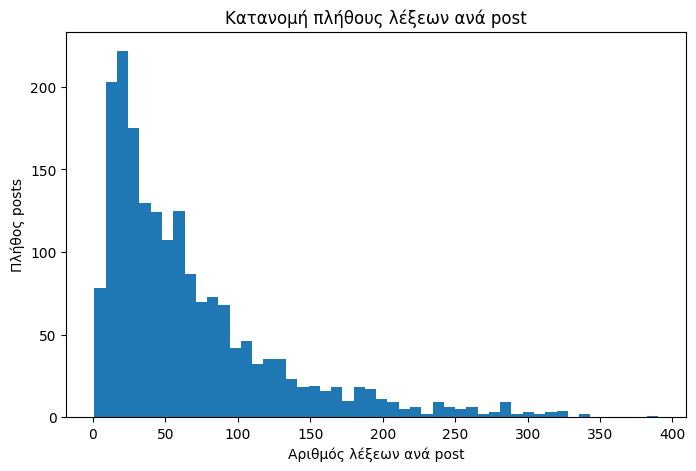

In [ ]:
# ιστόγραμμα

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_final["word_len"], bins=50)
plt.xlabel("Αριθμός λέξεων ανά post")
plt.ylabel("Πλήθος posts")
plt.title("Κατανομή πλήθους λέξεων ανά post")
plt.show()

Με βάση το πιο πάνω ιστόγραμμα, παρατηρούμε ότι υπάρχουν πολλά posts με λίγες λέξεις (10-50), ενώ πολύ λίγα Posts έχουν πολλές λέξεις. Δηλαδή, υπάρχει δεξιά ουρά στην κατανομή.

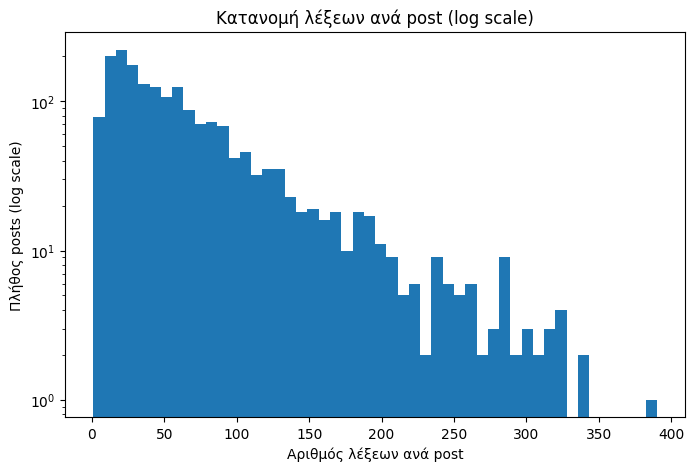

In [ ]:
# ιστόγραμμα με log κλίμακα

plt.figure(figsize=(8,5))
plt.hist(df_final["word_len"], bins=50)
plt.yscale("log")  # LOG στον άξονα y
plt.xlabel("Αριθμός λέξεων ανά post")
plt.ylabel("Πλήθος posts (log scale)")
plt.title("Κατανομή λέξεων ανά post (log scale)")
plt.show()

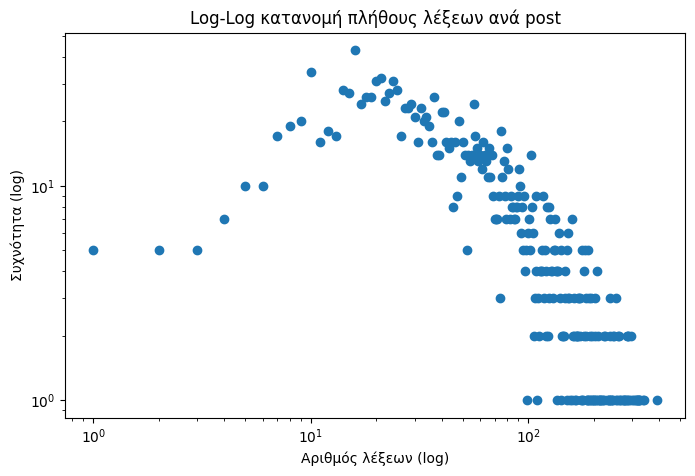

In [ ]:
# συχνότητα κάθε μήκους
word_counts = df_final["word_len"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(word_counts.index, word_counts.values, marker="o", linestyle="none")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Αριθμός λέξεων (log)")
plt.ylabel("Συχνότητα (log)")
plt.title("Log-Log κατανομή πλήθους λέξεων ανά post")
plt.show()

Με βάση τα πιο πάνω διαγράμματα, συμπεραίνουμε ότι η κατανομή του πλήθους λέξεων ανά post είναι long-tail, καθώς τα περισσότερα posts περιέχουν μικρό αριθμό λέξεων.

In [ ]:
###emojis-πόσα και πόσο συχνά###
import emoji
import pandas as pd

#έλεγχος αν το text είναι string
df_final["text"] = df_final["text"].astype(str)

#Function για καταμέτρηση emojis σε ένα text
def count_emojis(text):
    return sum(char in emoji.EMOJI_DATA for char in text)

#εφαρμογή στο dataset
df_final["emoji_count"] = df_final["text"].apply(count_emojis)

#statistics
print(df_final["emoji_count"].describe())

print(df_final["emoji_count"].value_counts().head())

#αναλογία ποστς με τουλαχιστον 1 emoji
df_final["has_emoji"] = df_final["emoji_count"] > 0
print(df_final["has_emoji"].value_counts(normalize=True))


count    1881.000000
mean        2.837321
std         3.943364
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max        40.000000
Name: emoji_count, dtype: float64
emoji_count
0    595
1    306
2    284
3    182
4    118
Name: count, dtype: int64
has_emoji
True     0.683679
False    0.316321
Name: proportion, dtype: float64


In [ ]:
###hashtags- clean dataset###

import re

#Function to count hashtags
def count_hashtags(text):
    #Finds words that start with "#"
    return len(re.findall(r"#\w+", text))

df_final["hashtag_count"] = df_final["text"].astype(str).apply(count_hashtags)

#statistics
df_final["hashtag_count"].describe()

,hashtag_count
count,1881.000000
mean,4.993620
std,5.307358
min,0.000000
25%,1.000000
50%,4.000000
75%,7.000000
max,31.000000


In [ ]:
###πόσα ποστς έχουν χασταγκ##
df_final["has_hashtag"] = df_final["hashtag_count"] > 0
df_final["has_hashtag"].value_counts(normalize=True)

,proportion
has_hashtag,
True,0.787879
False,0.212121


In [ ]:
###τα πιο συχνά χασταγκς είναι:
def extract_hashtags(text):
    return re.findall(r"#\w+", text)

all_hashtags = df_final["text"].astype(str).apply(extract_hashtags)

#Flatten the list
flat_hashtags = [ht.lower() for sublist in all_hashtags for ht in sublist]

import pandas as pd
pd.Series(flat_hashtags).value_counts().head(20)

,count
#news,75
#greece,74
#tanea,69
#taneagr,67
#ad,45
#ingr,43
#athens,40
#fyp,34
#megatv,32
#insnapshot,29


In [ ]:
import re

def extract_hashtags2(text):
    text = str(text)  # σε περίπτωση που έχει NaN
    return re.findall(r"#(\S+)", text)


In [ ]:
df_final["all_hashtags"] = df_final["text"].apply(extract_hashtags2)

In [ ]:
from collections import Counter

hashtag_counter = Counter()

for tags in df_final["all_hashtags"]:
    hashtag_counter.update(tags)

hashtag_counter.most_common(20)


[('tanea', 68),
 ('news', 68),
 ('taneagr', 67),
 ('greece', 64),
 ('ingr', 43),
 ('ad', 39),
 ('fyp', 33),
 ('athens', 32),
 ('insnapshot', 29),
 ('ant1tv', 26),
 ('ΕΡΤ1', 21),
 ('megatv', 21),
 ('viral', 18),
 ('giveaway', 18),
 ('ΕΡΤ', 17),
 ('SkaitvGR', 17),
 ('newsit', 17),
 ('politics', 16),
 ('ΔΕΗ', 16),
 ('greek', 15)]

In [ ]:
###γλώσσα###

!pip install langid

In [ ]:
###τσεκαρω γλωσσα στο df_final###

import langid

# Αν έχει NaN στο text, το μετατρέπω σε κενή συμβολοσειρά
df_final["text_clean"] = df_final["text"].astype(str)

# langid για κάθε row
df_final["lang"], df_final["lang_conf"] = zip(*df_final["text_clean"].apply(langid.classify)) ###langid o kwdikos iso kathe glwssas


In [ ]:
###στατιστικά γλωσσών###

df_final["lang"].value_counts()


,count
lang,
el,1695
en,126
la,17
zh,5
qu,3
km,2
ar,2
pl,2
lb,2


In [ ]:
df_final["lang"].value_counts(normalize=True)

,proportion
lang,
el,0.901116
en,0.066986
la,0.009038
zh,0.002658
qu,0.001595
km,0.001063
ar,0.001063
pl,0.001063
lb,0.001063


In [ ]:
df_final["lang_conf"].describe()

,lang_conf
count,1881.000000
mean,-4114.198803
std,4239.142451
min,-25059.116345
25%,-5432.347811
50%,-2678.426645
75%,-1204.227520
max,9.061840


In [ ]:
import re

def detect_script_mix(text):
    greek = len(re.findall(r"[α-ωΑ-Ωάέήίύόώ]", text))
    latin = len(re.findall(r"[a-zA-Z]", text))

    if greek > 0 and latin > 0:
        return "mixed"
    elif greek > 0:
        return "greek"
    elif latin > 0:
        return "english"
    else:
        return "other"

df_final["script_type"] = df_final["text_clean"].apply(detect_script_mix)

In [ ]:
df_final["script_type"].value_counts(normalize=True)

,proportion
script_type,
mixed,0.843169
english,0.090377
greek,0.063796
other,0.002658


#Σύνοψη

#Emojis
*   ~68% των κειμένων περιέχουν emojis
*   Μέσος όρος: 2,8 emojis ανά post
*   Έως και 40 emojis σε ορισμένα posts


Δηλαδή, τα emojis είναι σημαντικά για το συναίσθημα, ιδίως για το expressed sentiment. Άρα το μοντέλο πρέπει να:


*   χειρίζεται emojis σωστά,
*   προτιμήσουμε μοντέλα multilingual / social-media capable, ώστε να μην κάνουμε κάποια κανονικοποίηση- αγνόηση emojis και να χαθεί πληροφορία.

#Hashtags


*   Μέσος αριθμός hashtags: 5 ανά post
*   ~79% των posts έχουν τουλάχιστον 1 hashtag
*   Τα πιο συχνά hashtags σχετίζονται με ειδήσεις, brands, πόλεις κ.λπ.
(#news, #greece, #tanea, #fyp, #athens, #interamerican…)


Τα hashtags είναι συχνά στα αγγλικά, ακόμα και σε ελληνικά Posts. Φέρουν κυρίως πληροφορία topic, όχι πάντα sentiment, όμως μερικές φορές έχουν και συναισθηματικό χρώμα (#giveaway, #viral κ.λπ.)
Άρα δεν πρέπει να τα αφαιρέσουμε. Χρειάζεται tokenizer που χειρίζεται καλά subwords και Unicode → XLM-R, mBERT.









#Γλώσσες
(με langid)


*   90% των posts → el (Greek)
*   6,7% → en (English)
*   Το υπόλοιπο μοιράζεται σε πολύ μικρά ποσοστά.

Το dataset είναι κυρίως ελληνικό, όμως περιέχει αρκετές αγγλικές λέξεις με αποτέλεσμα να μην χρησιμοποιήσουμε καθαρά ελληνικό μοντέλο, αλλά να προτιμήσουμε multilingual transformer.

Script analysis:
Greek vs Latin

Παρότι το langid δίνει Greek στο 90%:


*   84% των posts είναι mixed script (έχουν και ελληνικούς και λατινικούς χαρακτήρες)
*   Μόνο 6% είναι καθαρά ελληνικά και ~9% καθαρά αγγλικά

Προκύπτει mixed script διότι τα περισσότερα posts περιέχουν:
*   hashtags στα λατινικά,
*   emojis,
*   brand names,
*   αγγλικές λέξεις μέσα σε ελληνικό κείμενο

Συνεπώς, τα μοντέλα Greek-only (GreekBERT, GreekRoBERTa) δεν είναι κατάλληλα, γιατί:
*   δεν έχουν εκπαιδευτεί σε mixed Greek-English social media data,
*   χάνουν ακρίβεια όταν η είσοδος έχει Latin script.








# Συμπεραίνουμε: #
*   ΟΧΙ Greek-only models
(π.χ. GreekBERT, GreekRoBERTa, GreekBART)- (Greek model μπορεί να χρησιμοποιηθεί σε induced sentiment, αν κάνουμε prompt-based reasonining (LLM), αλλά ΟΧΙ για βασικό text encoder).

Προτεινόμενα text encoders:

*   XLM-RoBERTa Base: Καλύτερο σε multilingual social media data, Πολύ καλό subword tokenizer για hashtags, emojis, Ισχυρό baseline για classification
*   mBERT: Λιγότερο ισχυρό αλλά σταθερό


*   LLMs με few-shot prompting για induced sentiment: (reasoning)
LLaMA 3.1, Qwen 2.5



In [ ]:
###υπολογισμός μεγέθους ντατασετ για πόρους###

###πόσα δείγματα###
print("RAW (pkl) rows:", data.shape)
print("CLEAN (final) rows:", df_final.shape)

RAW (pkl) rows: (11191, 16)
CLEAN (final) rows: (1881, 23)


In [ ]:
###token stats - clean dataset###
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

df_final["token_len"] = df_final["text"].astype(str).apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

print(df_final["token_len"].describe())
print("Share > 512 tokens:", (df_final["token_len"] > 512).mean())

Token indices sequence length is longer than the specified maximum sequence length for this model (556 > 512). Running this sequence through the model will result in indexing errors


count    1881.000000
mean      146.780436
std       124.444032
min         4.000000
25%        58.000000
50%       111.000000
75%       189.000000
max       847.000000
Name: token_len, dtype: float64
Share > 512 tokens: 0.02658160552897395


In [ ]:
import pandas as pd

# ασφάλεια: κάνουμε όλα string
texts = df_final["text"].astype(str)

# bytes ανά γραμμή (UTF-8)
text_bytes_per_row = texts.apply(lambda s: len(s.encode("utf-8")))

total_bytes = int(text_bytes_per_row.sum())
total_mb = total_bytes / (1024**2)
total_gb = total_bytes / (1024**3)

print("Total text size (bytes):", total_bytes)
print("Total text size (MB):", total_mb)
print("Total text size (GB):", total_gb)

print("\nPer-text stats (bytes):")
print(text_bytes_per_row.describe())

Total text size (bytes): 1405129
Total text size (MB): 1.3400354385375977
Total text size (GB): 0.0013086283579468727

Per-text stats (bytes):
count    1881.000000
mean      747.011696
std       687.882830
min         4.000000
25%       254.000000
50%       537.000000
75%       996.000000
max      3929.000000
Name: text, dtype: float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
images_folder = "/content/drive/MyDrive/matched_images"

In [ ]:
from pathlib import Path

def folder_size_gb(folder):
    folder = Path(folder)
    total = sum(p.stat().st_size for p in folder.rglob("*") if p.is_file())
    return total / (1024**3)

print("Images size (GB):", folder_size_gb(images_folder))

Images size (GB): 1.6024052519351244


In [ ]:
from pathlib import Path

images_folder = "/content/drive/MyDrive/matched_images"

num_images = len(list(Path(images_folder).glob("*.jpg")))
print("Αριθμός εικόνων:", num_images)


Αριθμός εικόνων: 10699


In [ ]:
from pathlib import Path

images_folder = "/content/drive/MyDrive/matched_images"

extensions = ["*.jpg", "*.jpeg", "*.png"]
num_images = sum(len(list(Path(images_folder).glob(ext))) for ext in extensions)

print("Σύνολο εικόνων:", num_images)


Σύνολο εικόνων: 10702


LABEL CLEANING- διότι τα labels δεν είναι κανονικοποιημένα (case inconsistency)- π.χ. Neutral και neutral.

In [ ]:
for col in ["voted_expressed", "voted_induced"]:
    df_final[col] = df_final[col].astype(str).str.strip().str.lower()

In [ ]:
df_final["voted_expressed"].value_counts()

,count
voted_expressed,
neutral,997
positive,585
negative,299


In [ ]:
df_final["voted_induced"].value_counts()

,count
voted_induced,
positive,1362
negative,340
neutral,179


**ΠΕΙΡΑΜΑ 1**
Multilingual baseline


*   Input: text_clean
*   Label: voted_expressed
*   Model: xlm-roberta-base
*   Output: accuracy + macro-F1




In [ ]:
df_final[["raw_response", "text", "text_clean"]].head(3)


,raw_response,text,text_clean
0,EXPRESSED_SENTIMENT: negative\nEXPRESSED_CONF...,Δικαιοσύνη ή οικογένεια;🤔 Τι θα διάλεγες αν ήσ...,Δικαιοσύνη ή οικογένεια;🤔 Τι θα διάλεγες αν ήσ...
1,EXPRESSED_SENTIMENT: neutral\nEXPRESSED_CONFI...,Δεν προχώρησε τελικά... 👉 Το #5x5 με τον Θάνο ...,Δεν προχώρησε τελικά... 👉 Το #5x5 με τον Θάνο ...
2,EXPRESSED_SENTIMENT: positive\nEXPRESSED_CONF...,Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! 💘...,Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! 💘...


In [ ]:
i = 0
print("RAW:\n", df_final.loc[i, "raw_response"][:400])
print("\nCLEAN:\n", df_final.loc[i, "text_clean"])

RAW:
  EXPRESSED_SENTIMENT: negative
EXPRESSED_CONFIDENCE: 90
EXPRESSED_EXPLANATION: The man's facial expression, with furrowed brows and a serious demeanor, suggests a negative sentiment.

INDUCED_SENTIMENT: neutral
INDUCED_CONFIDENCE: 50
INDUCED_EXPLANATION: The image itself does not evoke a strong emotional response, as it appears to be a staged or professional setting.

COMPARISON: The expressed sen

CLEAN:
 Δικαιοσύνη ή οικογένεια;🤔 Τι θα διάλεγες αν ήσουν στη θέση του Δικαστή; ⚖️ «Ο Δικαστής» είναι κάθε Κυριακή και Δευτέρα στις 22:30 στον ANT1. #ant1tv #dikastis


In [ ]:
(df_final["text"] == df_final["text_clean"]).mean()


np.float64(1.0)

In [ ]:
# =========================
# Επιλογή input & target
# =========================

TEXT_COLUMN = "text_clean"
LABEL_COLUMN = "voted_expressed"

df_final[[TEXT_COLUMN, LABEL_COLUMN]].head()

,text_clean,voted_expressed
0,Δικαιοσύνη ή οικογένεια;🤔 Τι θα διάλεγες αν ήσ...,negative
1,Δεν προχώρησε τελικά... 👉 Το #5x5 με τον Θάνο ...,neutral
2,Εδώ υπάρχει μία αδυναμία στις Θεσσαλονικιές! 💘...,positive
3,"🦠 Με συχνότητα εμφάνισης 3,4 στους 1.000 υγιεί...",negative
4,Ουκρανία: Επιβεβαίωσε την επίθεση σε βάση ρωσι...,negative


In [ ]:
###Label encoding###

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_final["label_id"] = label_encoder.fit_transform(df_final[LABEL_COLUMN])

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_final,
    test_size=0.2,
    stratify=df_final["label_id"],
    random_state=42
)

train_df.shape, val_df.shape

((1504, 24), (377, 24))

In [ ]:
!pip -q install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00


In [ ]:
from datasets import Dataset

TEXT_COLUMN = "text_clean"
# LABEL_COLUMN = "voted_expressed"

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

train_ds, val_ds

(Dataset({
     features: ['text_clean', 'label_id'],
     num_rows: 1504
 }),
 Dataset({
     features: ['text_clean', 'label_id'],
     num_rows: 377
 }))

In [ ]:
from transformers import AutoTokenizer

model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN])
val_tok   = val_tok.remove_columns([TEXT_COLUMN])

train_tok = train_tok.rename_column("label_id", "labels")
val_tok   = val_tok.rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
from transformers import TrainingArguments, Trainer

import os
os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir="./xlmr_expressed",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipython-input-2543315506.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.969900,0.906826,0.522546,0.228804
2,0.886300,0.897535,0.538462,0.259443
3,0.820000,0.860491,0.586207,0.519585


TrainOutput(global_step=564, training_loss=0.9098679833378353, metrics={'train_runtime': 452.9019, 'train_samples_per_second': 9.962, 'train_steps_per_second': 1.245, 'total_flos': 593583870394368.0, 'train_loss': 0.9098679833378353, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 27  30   3]
 [ 19 158  23]
 [  9  72  36]]
              precision    recall  f1-score   support

    negative       0.49      0.45      0.47        60
     neutral       0.61      0.79      0.69       200
    positive       0.58      0.31      0.40       117

    accuracy                           0.59       377
   macro avg       0.56      0.52      0.52       377
weighted avg       0.58      0.59      0.56       377



Στην αρχική πειραματική φάση χρησιμοποιήθηκε το πολυγλωσσικό μοντέλο XLM-RoBERTa ως baseline για την ανάλυση συναισθήματος. Το μοντέλο αυτό έχει εκπαιδευτεί σε μεγάλο όγκο πολυγλωσσικών δεδομένων και είναι κατάλληλο για κείμενα που περιέχουν περισσότερες από μία γλώσσες. Στην περίπτωσή μας, το μοντέλο χρησιμοποιήθηκε αποκλειστικά για ανάλυση κειμένου, χωρίς περαιτέρω προσαρμογή για emojis ή hashtags.

Τα αποτελέσματα της βασικής προσέγγισης δείχνουν ότι το πολυγλωσσικό μοντέλο επιτυγχάνει ικανοποιητική συνολική απόδοση, με ακρίβεια περίπου 59% και macro-F1 ίσο με 0.52. Η ανάλυση του πίνακα σύγχυσης αποκαλύπτει ότι το μοντέλο προβλέπει αποτελεσματικότερα την ουδέτερη κατηγορία, ενώ δυσκολεύεται περισσότερο στη διάκριση μεταξύ θετικού και ουδέτερου συναισθήματος. Το φαινόμενο αυτό αποδίδεται εν μέρει στην απουσία ειδικής αναπαράστασης για emojis και hashtags, τα οποία συχνά μεταφέρουν κρίσιμη πληροφορία για το συναίσθημα στα δεδομένα κοινωνικών δικτύων.

Για να απομονωθεί η επίδραση της προεπεξεργασίας του κειμένου, όλες οι πειραματικές παραλλαγές υλοποιούνται χρησιμοποιώντας το ίδιο πολυγλωσσικό μοντέλο (XLM-RoBERTa), διατηρώντας σταθερές τις υπόλοιπες παραμέτρους εκπαίδευσης.

EMOJI MORMALIZATION

In [ ]:
!pip install emoji

In [ ]:
import emoji
import re

def normalize_emojis(text):
    if not isinstance(text, str):
        return text
    return emoji.demojize(
        text,
        delimiters=(" <EMO_", "> ")
    )

In [ ]:
##test

sample = "Τέλειο 😍🔥 #ant1"
print("ΠΡΙΝ :", sample)
print("ΜΕΤΑ :", normalize_emojis(sample))

ΠΡΙΝ : Τέλειο 😍🔥 #ant1
ΜΕΤΑ : Τέλειο  <EMO_smiling_face_with_heart-eyes>  <EMO_fire>  #ant1


In [ ]:
df_final["text_emoji"] = df_final["text_clean"].apply(normalize_emojis)

In [ ]:
df_final[["text_clean", "text_emoji"]].sample(5)

,text_clean,text_emoji
1113,Οδηγός βοηθειών ! 🤭🪵 #mountaintea #pavliani #d...,Οδηγός βοηθειών ! <EMO_face_with_hand_over_mo...
593,"Ένα ιδιαίτερα έντονο χαρμάνι, πλούσιος με γεμά...","Ένα ιδιαίτερα έντονο χαρμάνι, πλούσιος με γεμά..."
598,Η εμπειρία φιλοξενίας στα Νότια επαναπροσδιορί...,Η εμπειρία φιλοξενίας στα Νότια επαναπροσδιορί...
743,Πάρε τώρα το δικό σου εισιτήριο για να μην περ...,Πάρε τώρα το δικό σου εισιτήριο για να μην περ...
1009,Πεντανόστιμα πιτάκια με γέμιση κιμά αλλά @aki...,Πεντανόστιμα πιτάκια με γέμιση κιμά αλλά @aki...


In [ ]:
train_df["text_emoji"] = train_df["text_clean"].apply(normalize_emojis)
val_df["text_emoji"]   = val_df["text_clean"].apply(normalize_emojis)

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

TEXT_COLUMN = "text_emoji"
model_name = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(label_encoder.classes_)
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

trainer.train()

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.987000,0.943309,0.530504,0.231080
2,0.899600,0.903986,0.564987,0.432817
3,0.829400,0.847238,0.596817,0.512386


TrainOutput(global_step=564, training_loss=0.9278078011587156, metrics={'train_runtime': 473.592, 'train_samples_per_second': 9.527, 'train_steps_per_second': 1.191, 'total_flos': 593583870394368.0, 'train_loss': 0.9278078011587156, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 20  39   1]
 [ 11 168  21]
 [  4  76  37]]
              precision    recall  f1-score   support

    negative       0.57      0.33      0.42        60
     neutral       0.59      0.84      0.70       200
    positive       0.63      0.32      0.42       117

    accuracy                           0.60       377
   macro avg       0.60      0.50      0.51       377
weighted avg       0.60      0.60      0.57       377



Η εφαρμογή κανονικοποίησης των emojis οδήγησε σε βελτίωση της απόδοσης του μοντέλου στην αναγνώριση θετικού συναισθήματος, όπως αποτυπώνεται στην αύξηση του F1-score και του recall της αντίστοιχης κατηγορίας. Παρότι η συνολική τιμή του macro-F1 παρέμεινε σε παρόμοια επίπεδα, η στοχευμένη βελτίωση στην κατηγορία του θετικού συναισθήματος υποδηλώνει ότι τα emojis μεταφέρουν κρίσιμη συναισθηματική πληροφορία, η οποία δεν αξιοποιείται επαρκώς από το βασικό μοντέλο χωρίς προσαρμογή.

HASHTAG NORMALIZATION

In [ ]:
import re

def normalize_hashtags(text):
    if not isinstance(text, str):
        return text

    def repl(match):
        tag = match.group(1)
        return f" <HASHTAG> {tag} "

    return re.sub(r"#(\w+)", repl, text)

In [ ]:
###test
sample = "Τέλειο 😍 #ant1 #ντροπή"
print("ΠΡΙΝ :", sample)
print("META :", normalize_hashtags(sample))

ΠΡΙΝ : Τέλειο 😍 #ant1 #ντροπή
META : Τέλειο 😍  <HASHTAG> ant1   <HASHTAG> ντροπή 


In [ ]:
df_final["text_emoji_hash"] = df_final["text_emoji"].apply(normalize_hashtags)

df_final[["text_clean", "text_emoji", "text_emoji_hash"]].sample(5)

,text_clean,text_emoji,text_emoji_hash
1113,Οδηγός βοηθειών ! 🤭🪵 #mountaintea #pavliani #d...,Οδηγός βοηθειών ! <EMO_face_with_hand_over_mo...,Οδηγός βοηθειών ! <EMO_face_with_hand_over_mo...
593,"Ένα ιδιαίτερα έντονο χαρμάνι, πλούσιος με γεμά...","Ένα ιδιαίτερα έντονο χαρμάνι, πλούσιος με γεμά...","Ένα ιδιαίτερα έντονο χαρμάνι, πλούσιος με γεμά..."
598,Η εμπειρία φιλοξενίας στα Νότια επαναπροσδιορί...,Η εμπειρία φιλοξενίας στα Νότια επαναπροσδιορί...,Η εμπειρία φιλοξενίας στα Νότια επαναπροσδιορί...
743,Πάρε τώρα το δικό σου εισιτήριο για να μην περ...,Πάρε τώρα το δικό σου εισιτήριο για να μην περ...,Πάρε τώρα το δικό σου εισιτήριο για να μην περ...
1009,Πεντανόστιμα πιτάκια με γέμιση κιμά αλλά @aki...,Πεντανόστιμα πιτάκια με γέμιση κιμά αλλά @aki...,Πεντανόστιμα πιτάκια με γέμιση κιμά αλλά @aki...


In [ ]:
train_df["text_emoji_hash"] = train_df["text_emoji"].apply(normalize_hashtags)
val_df["text_emoji_hash"]   = val_df["text_emoji"].apply(normalize_hashtags)

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

TEXT_COLUMN = "text_emoji_hash"
model_name = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.987900,0.970611,0.530504,0.231080
2,0.938000,0.920222,0.533156,0.257535
3,0.886100,0.856464,0.602122,0.523132


TrainOutput(global_step=564, training_loss=0.9555804475824884, metrics={'train_runtime': 595.7913, 'train_samples_per_second': 7.573, 'train_steps_per_second': 0.947, 'total_flos': 593583870394368.0, 'train_loss': 0.9555804475824884, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 20  38   2]
 [ 16 163  21]
 [  5  68  44]]
              precision    recall  f1-score   support

    negative       0.49      0.33      0.40        60
     neutral       0.61      0.81      0.70       200
    positive       0.66      0.38      0.48       117

    accuracy                           0.60       377
   macro avg       0.58      0.51      0.52       377
weighted avg       0.60      0.60      0.58       377



Η συνδυαστική κανονικοποίηση emojis και hashtags οδήγησε σε σημαντική βελτίωση του recall και του F1-score της θετικής κατηγορίας, αυξάνοντας τον αριθμό των σωστά αναγνωρισμένων θετικών παραδειγμάτων. Παρότι η συνολική τιμή του macro-F1 παρέμεινε σταθερή, η ποιοτική βελτίωση στην αναγνώριση θετικού συναισθήματος υποδηλώνει ότι τα emojis και τα hashtags μεταφέρουν σημαντική συναισθηματική πληροφορία, η οποία μπορεί να αξιοποιηθεί αποτελεσματικά μέσω απλών τεχνικών προεπεξεργασίας, χωρίς τροποποίηση της αρχιτεκτονικής του μοντέλου.

In [ ]:
import pandas as pd

results_xlmr = pd.DataFrame({
    "Preprocessing": [
        "Baseline (text_clean)",
        "Emoji normalization",
        "Emoji + Hashtag processing"
    ],
    "Accuracy": [
        0.59,
        0.60,
        0.60
    ],
    "Macro-F1": [
        0.52,
        0.51,
        0.52
    ],
    "Positive Precision": [
        0.58,
        0.63,
        0.66
    ],
    "Positive Recall": [
        0.31,
        0.32,
        0.38
    ],
    "Positive F1": [
        0.40,
        0.42,
        0.48
    ]
})

results_xlmr


,Preprocessing,Accuracy,Macro-F1,Positive Precision,Positive Recall,Positive F1
0,Baseline (text_clean),0.59,0.52,0.58,0.31,0.40
1,Emoji normalization,0.60,0.51,0.63,0.32,0.42
2,Emoji + Hashtag processing,0.60,0.52,0.66,0.38,0.48


ΠΕΙΡΑΜΑ ΜΕ MBERT

In [ ]:
model_name = "bert-base-multilingual-cased"

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
TEXT_COLUMN = "text_clean"

In [ ]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.985500,0.936033,0.530504,0.231080
2,0.914000,0.901791,0.541114,0.367753
3,0.802000,0.913480,0.570292,0.480762


TrainOutput(global_step=564, training_loss=0.9118052272931904, metrics={'train_runtime': 304.2492, 'train_samples_per_second': 14.83, 'train_steps_per_second': 1.854, 'total_flos': 593583870394368.0, 'train_loss': 0.9118052272931904, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 26  32   2]
 [ 20 166  14]
 [  6  88  23]]
              precision    recall  f1-score   support

    negative       0.50      0.43      0.46        60
     neutral       0.58      0.83      0.68       200
    positive       0.59      0.20      0.29       117

    accuracy                           0.57       377
   macro avg       0.56      0.49      0.48       377
weighted avg       0.57      0.57      0.53       377



EMOJIS NORMALIZATION

In [ ]:
train_df["text_emoji"].head()
val_df["text_emoji"].head()

,text_emoji
1304,Μια μοναδική βιωματική εμπειρία που μας έφερε ...
554,"Ένας Ολυμπιακός Αγώνας Δρόμου απαιτεί δύναμη, ..."
1368,<EMO_locked> Απόκτησε τις γνώσεις και την πι...
407,ΜΥΡΙΖΟΜΑΙ ΔΙΑΓΩΝΙΣΜΟ! \n <EMO_eyes> Είδες περ...
639,#ad Έχεις ακόμη απορίες με τον λογαριασμό ρεύμ...


In [ ]:
from datasets import Dataset

TEXT_COLUMN = "text_emoji"

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

model_name = "bert-base-multilingual-cased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.966300,0.946288,0.530504,0.231080
2,0.910300,0.913548,0.527851,0.339280
3,0.837200,0.891160,0.554377,0.473217


TrainOutput(global_step=564, training_loss=0.9247047478425587, metrics={'train_runtime': 230.8298, 'train_samples_per_second': 19.547, 'train_steps_per_second': 2.443, 'total_flos': 593583870394368.0, 'train_loss': 0.9247047478425587, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 24  34   2]
 [ 21 158  21]
 [  6  84  27]]
              precision    recall  f1-score   support

    negative       0.47      0.40      0.43        60
     neutral       0.57      0.79      0.66       200
    positive       0.54      0.23      0.32       117

    accuracy                           0.55       377
   macro avg       0.53      0.47      0.47       377
weighted avg       0.55      0.55      0.52       377



HASHTAG NORMALIZATION

In [ ]:
import re

def normalize_hashtags(text):
    if not isinstance(text, str):
        return text


    hashtags = re.findall(r"#\w+", text)

    for h in hashtags:
        clean = h[1:]
        clean = re.sub(r"([a-zA-Z]+)(\d+)", r"\1 \2", clean)
        clean = re.sub(r"(\d+)([a-zA-Z]+)", r"\1 \2", clean)

        clean = clean.replace("_", " ")
        text = text.replace(h, clean)

    return text

In [ ]:
train_df["text_hashtag"] = train_df["text_emoji"].apply(normalize_hashtags)
val_df["text_hashtag"]   = val_df["text_emoji"].apply(normalize_hashtags)

In [ ]:
train_df[["text_emoji", "text_hashtag"]].head(5)

,text_emoji,text_hashtag
1085,Ο Κωνσταντίνος Αργυρός ερμηνεύει το «Αχ καρδιά...,Ο Κωνσταντίνος Αργυρός ερμηνεύει το «Αχ καρδιά...
1501,<EMO_woman_running> <EMO_man_running> <EMO_...,<EMO_woman_running> <EMO_man_running> <EMO_...
1827,<EMO_sparkles> Ο φετινός τελικός του Funtast...,<EMO_sparkles> Ο φετινός τελικός του Funtast...
170,Μαζί μπορούμε να κάνουμε τη διαφορά! <EMO_blu...,Μαζί μπορούμε να κάνουμε τη διαφορά! <EMO_blu...
1137,Χειμερινό Πρόγραμμα 𝐌𝐎𝐃𝐎 𝐃𝐈 𝐕𝐈𝐓𝐀 <EMO_victory...,Χειμερινό Πρόγραμμα 𝐌𝐎𝐃𝐎 𝐃𝐈 𝐕𝐈𝐓𝐀 <EMO_victory...


In [ ]:
from datasets import Dataset

TEXT_COLUMN = "text_hashtag"

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

model_name = "bert-base-multilingual-cased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

training_args.output_dir = "./mbert_hashtag"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.949800,0.931398,0.530504,0.251200
2,0.863300,0.920057,0.533156,0.371684
3,0.762300,0.921878,0.580902,0.502170


TrainOutput(global_step=564, training_loss=0.8836975774021013, metrics={'train_runtime': 230.5291, 'train_samples_per_second': 19.572, 'train_steps_per_second': 2.447, 'total_flos': 593583870394368.0, 'train_loss': 0.8836975774021013, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 24  34   2]
 [ 21 162  17]
 [  6  78  33]]
              precision    recall  f1-score   support

    negative       0.47      0.40      0.43        60
     neutral       0.59      0.81      0.68       200
    positive       0.63      0.28      0.39       117

    accuracy                           0.58       377
   macro avg       0.57      0.50      0.50       377
weighted avg       0.59      0.58      0.55       377



In [ ]:
import pandas as pd

results_mbert = pd.DataFrame({
    "Preprocessing": [
        "Baseline (text_clean)",
        "Emoji normalization",
        "Emoji + Hashtag processing"
    ],
    "Accuracy": [0.57, 0.58, 0.58],
    "Macro-F1": [0.48, 0.50, 0.50],
    "Positive Precision": [0.59, 0.63, 0.54],
    "Positive Recall": [0.20, 0.28, 0.23],
    "Positive F1": [0.29, 0.39, 0.32],
})

results_mbert

,Preprocessing,Accuracy,Macro-F1,Positive Precision,Positive Recall,Positive F1
0,Baseline (text_clean),0.57,0.48,0.59,0.20,0.29
1,Emoji normalization,0.58,0.50,0.63,0.28,0.39
2,Emoji + Hashtag processing,0.58,0.50,0.54,0.23,0.32


In [ ]:
compare_models = pd.concat(
    [results_xlmr.assign(Model="XLM-R"), results_mbert.assign(Model="mBERT")],
    ignore_index=True
)

compare_models = compare_models[[
    "Model","Preprocessing","Accuracy","Macro-F1",
    "Positive Precision","Positive Recall","Positive F1"
]]

compare_models

,Model,Preprocessing,Accuracy,Macro-F1,Positive Precision,Positive Recall,Positive F1
0,XLM-R,Baseline (text_clean),0.59,0.52,0.58,0.31,0.40
1,XLM-R,Emoji normalization,0.60,0.51,0.63,0.32,0.42
2,XLM-R,Emoji + Hashtag processing,0.60,0.52,0.66,0.38,0.48
3,mBERT,Baseline (text_clean),0.57,0.48,0.59,0.20,0.29
4,mBERT,Emoji normalization,0.58,0.50,0.63,0.28,0.39
5,mBERT,Emoji + Hashtag processing,0.58,0.50,0.54,0.23,0.32


ΠΕΙΡΑΜΑ GREEKBERT

In [ ]:
model_name = "nlpaueb/bert-base-greek-uncased-v1"

from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
TEXT_COLUMN = "text_clean"

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/bert-base-greek-uncased-v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.897100,0.874004,0.594164,0.467896
2,0.769600,0.866847,0.586207,0.554694
3,0.629100,0.860258,0.604775,0.562960


TrainOutput(global_step=564, training_loss=0.8001058727291459, metrics={'train_runtime': 155.7514, 'train_samples_per_second': 28.969, 'train_steps_per_second': 3.621, 'total_flos': 593583870394368.0, 'train_loss': 0.8001058727291459, 'epoch': 3.0})

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)

print(confusion_matrix(pred.label_ids, preds))
print(classification_report(pred.label_ids, preds, target_names=label_encoder.classes_))

[[ 29  27   4]
 [ 18 148  34]
 [  6  60  51]]
              precision    recall  f1-score   support

    negative       0.55      0.48      0.51        60
     neutral       0.63      0.74      0.68       200
    positive       0.57      0.44      0.50       117

    accuracy                           0.60       377
   macro avg       0.58      0.55      0.56       377
weighted avg       0.60      0.60      0.60       377



EMOJI NORMALIZATION

In [ ]:
train_df["text_emoji"].head()
val_df["text_emoji"].head()

,text_emoji
1304,Μια μοναδική βιωματική εμπειρία που μας έφερε ...
554,"Ένας Ολυμπιακός Αγώνας Δρόμου απαιτεί δύναμη, ..."
1368,locked Απόκτησε τις γνώσεις και την πιστοποί...
407,ΜΥΡΙΖΟΜΑΙ ΔΙΑΓΩΝΙΣΜΟ! \n eyes Είδες περίεργο ...
639,#ad Έχεις ακόμη απορίες με τον λογαριασμό ρεύμ...


In [ ]:
from datasets import Dataset

TEXT_COLUMN = "text_emoji"

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

model_name = "nlpaueb/bert-base-greek-uncased-v1"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/bert-base-greek-uncased-v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.894500,0.867567,0.562334,0.425479
2,0.772700,0.862411,0.586207,0.568379
3,0.640000,0.848955,0.586207,0.551487


TrainOutput(global_step=564, training_loss=0.7961631193228648, metrics={'train_runtime': 145.4923, 'train_samples_per_second': 31.012, 'train_steps_per_second': 3.876, 'total_flos': 593583870394368.0, 'train_loss': 0.7961631193228648, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 36  21   3]
 [ 25 126  49]
 [ 10  48  59]]
              precision    recall  f1-score   support

    negative       0.51      0.60      0.55        60
     neutral       0.65      0.63      0.64       200
    positive       0.53      0.50      0.52       117

    accuracy                           0.59       377
   macro avg       0.56      0.58      0.57       377
weighted avg       0.59      0.59      0.59       377



HASHTAG NORMALIZATION

In [ ]:
import re

def normalize_hashtags(text):
    if not isinstance(text, str):
        return text


    hashtags = re.findall(r"#\w+", text)

    for h in hashtags:
        clean = h[1:]
        clean = re.sub(r"([a-zA-Z]+)(\d+)", r"\1 \2", clean)
        clean = re.sub(r"(\d+)([a-zA-Z]+)", r"\1 \2", clean)

        clean = clean.replace("_", " ")
        text = text.replace(h, clean)

    return text

In [ ]:
train_df["text_hashtag"] = train_df["text_emoji"].apply(normalize_hashtags)
val_df["text_hashtag"]   = val_df["text_emoji"].apply(normalize_hashtags)

In [ ]:
from datasets import Dataset

TEXT_COLUMN = "text_hashtag"

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

model_name = "nlpaueb/bert-base-greek-uncased-v1"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

training_args.output_dir = "./mbert_hashtag"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/bert-base-greek-uncased-v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.896900,0.876796,0.551724,0.402168
2,0.804800,0.850812,0.607427,0.558641
3,0.683000,0.849766,0.596817,0.543410


TrainOutput(global_step=564, training_loss=0.8134325176266068, metrics={'train_runtime': 146.8606, 'train_samples_per_second': 30.723, 'train_steps_per_second': 3.84, 'total_flos': 593583870394368.0, 'train_loss': 0.8134325176266068, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))

[[ 34  26   0]
 [ 24 156  20]
 [  7  71  39]]
              precision    recall  f1-score   support

    negative       0.52      0.57      0.54        60
     neutral       0.62      0.78      0.69       200
    positive       0.66      0.33      0.44       117

    accuracy                           0.61       377
   macro avg       0.60      0.56      0.56       377
weighted avg       0.62      0.61      0.59       377



In [ ]:
import pandas as pd

results_greekbert = pd.DataFrame([
    {
        "Model": "GreekBERT (nlpaueb/bert-base-greek-uncased-v1)",
        "Preprocessing": "Baseline (text_clean)",
        "Accuracy": 0.60,
        "Macro-F1": 0.56,
        "Positive Precision": 0.57,
        "Positive Recall": 0.44,
        "Positive F1": 0.50,
    },
    {
        "Model": "GreekBERT (nlpaueb/bert-base-greek-uncased-v1)",
        "Preprocessing": "Emoji normalization",
        "Accuracy": 0.59,
        "Macro-F1": 0.57,
        "Positive Precision": 0.53,
        "Positive Recall": 0.50,
        "Positive F1": 0.52,
    },
    {
        "Model": "GreekBERT (nlpaueb/bert-base-greek-uncased-v1)",
        "Preprocessing": "Hashtag normalization",
        "Accuracy": 0.61,
        "Macro-F1": 0.56,
        "Positive Precision": 0.66,
        "Positive Recall": 0.33,
        "Positive F1": 0.44,
    },
])

results_greekbert



,Model,Preprocessing,Accuracy,Macro-F1,Positive Precision,Positive Recall,Positive F1
0,GreekBERT (nlpaueb/bert-base-greek-uncased-v1),Baseline (text_clean),0.60,0.56,0.57,0.44,0.50
1,GreekBERT (nlpaueb/bert-base-greek-uncased-v1),Emoji normalization,0.59,0.57,0.53,0.50,0.52
2,GreekBERT (nlpaueb/bert-base-greek-uncased-v1),Hashtag normalization,0.61,0.56,0.66,0.33,0.44


In [ ]:
import pandas as pd

# XLM-R
results_xlmr = pd.DataFrame([
    {"Model":"XLM-R (xlm-roberta-base)", "Preprocessing":"Baseline (text_clean)",        "Accuracy":0.59, "Macro-F1":0.52, "Positive Precision":0.58, "Positive Recall":0.31, "Positive F1":0.40},
    {"Model":"XLM-R (xlm-roberta-base)", "Preprocessing":"Emoji normalization",         "Accuracy":0.60, "Macro-F1":0.51, "Positive Precision":0.63, "Positive Recall":0.32, "Positive F1":0.42},
    {"Model":"XLM-R (xlm-roberta-base)", "Preprocessing":"Emoji + Hashtag processing",  "Accuracy":0.60, "Macro-F1":0.52, "Positive Precision":0.66, "Positive Recall":0.38, "Positive F1":0.48},
])

# mBERT
results_mbert = pd.DataFrame([
    {"Model":"mBERT (bert-base-multilingual-cased)", "Preprocessing":"Baseline (text_clean)",       "Accuracy":0.57, "Macro-F1":0.48, "Positive Precision":0.59, "Positive Recall":0.20, "Positive F1":0.29},
    {"Model":"mBERT (bert-base-multilingual-cased)", "Preprocessing":"Emoji normalization",        "Accuracy":0.55, "Macro-F1":0.47, "Positive Precision":0.54, "Positive Recall":0.23, "Positive F1":0.32},
    {"Model":"mBERT (bert-base-multilingual-cased)", "Preprocessing":"Hashtag normalization",      "Accuracy":0.57, "Macro-F1":0.50, "Positive Precision":0.63, "Positive Recall":0.28, "Positive F1":0.39},
])

# GreekBERT
results_greekbert = pd.DataFrame([
    {"Model":"GreekBERT (nlpaueb/bert-base-greek-uncased-v1)", "Preprocessing":"Baseline (text_clean)",  "Accuracy":0.60, "Macro-F1":0.56, "Positive Precision":0.57, "Positive Recall":0.44, "Positive F1":0.50},
    {"Model":"GreekBERT (nlpaueb/bert-base-greek-uncased-v1)", "Preprocessing":"Emoji normalization",   "Accuracy":0.59, "Macro-F1":0.57, "Positive Precision":0.53, "Positive Recall":0.50, "Positive F1":0.52},
    {"Model":"GreekBERT (nlpaueb/bert-base-greek-uncased-v1)", "Preprocessing":"Hashtag normalization", "Accuracy":0.61, "Macro-F1":0.56, "Positive Precision":0.66, "Positive Recall":0.33, "Positive F1":0.44},
])

comparison_all = pd.concat([results_xlmr, results_mbert, results_greekbert], ignore_index=True)


order = ["Baseline (text_clean)", "Emoji normalization", "Hashtag normalization", "Emoji + Hashtag processing"]
comparison_all["Preprocessing"] = pd.Categorical(comparison_all["Preprocessing"], categories=order, ordered=True)
comparison_all = comparison_all.sort_values(["Model","Preprocessing"]).reset_index(drop=True)

comparison_all


,Model,Preprocessing,Accuracy,Macro-F1,Positive Precision,Positive Recall,Positive F1
0,GreekBERT (nlpaueb/bert-base-greek-uncased-v1),Baseline (text_clean),0.60,0.56,0.57,0.44,0.50
1,GreekBERT (nlpaueb/bert-base-greek-uncased-v1),Emoji normalization,0.59,0.57,0.53,0.50,0.52
2,GreekBERT (nlpaueb/bert-base-greek-uncased-v1),Hashtag normalization,0.61,0.56,0.66,0.33,0.44
3,XLM-R (xlm-roberta-base),Baseline (text_clean),0.59,0.52,0.58,0.31,0.40
4,XLM-R (xlm-roberta-base),Emoji normalization,0.60,0.51,0.63,0.32,0.42
5,XLM-R (xlm-roberta-base),Emoji + Hashtag processing,0.60,0.52,0.66,0.38,0.48
6,mBERT (bert-base-multilingual-cased),Baseline (text_clean),0.57,0.48,0.59,0.20,0.29
7,mBERT (bert-base-multilingual-cased),Emoji normalization,0.55,0.47,0.54,0.23,0.32
8,mBERT (bert-base-multilingual-cased),Hashtag normalization,0.57,0.50,0.63,0.28,0.39


BERTweet

In [ ]:
!pip install -q transformers datasets emoji accelerate

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

TEXT_COLUMN = "text_emoji_hash"
MODEL_NAME  = "cardiffnlp/twitter-xlm-roberta-base"  # social-media native (XLM-T)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_pandas(train_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[TEXT_COLUMN, "label_id"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)

train_tok = train_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")
val_tok   = val_tok.remove_columns([TEXT_COLUMN]).rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/377 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoModelForSequenceClassification

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import os
from transformers import TrainingArguments, Trainer

os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir="./bertweet_xlmt",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()


/tmp/ipython-input-2622074600.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.982300,0.938374,0.530504,0.231080
2,0.905800,0.917354,0.562334,0.417681
3,0.869800,0.903097,0.549072,0.408062


TrainOutput(global_step=564, training_loss=0.9392369858762051, metrics={'train_runtime': 303.1419, 'train_samples_per_second': 14.884, 'train_steps_per_second': 1.861, 'total_flos': 593583870394368.0, 'train_loss': 0.9392369858762051, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

pred = trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=label_encoder.classes_))


[[ 27  33   0]
 [ 21 179   0]
 [ 10 101   6]]
              precision    recall  f1-score   support

    negative       0.47      0.45      0.46        60
     neutral       0.57      0.90      0.70       200
    positive       1.00      0.05      0.10       117

    accuracy                           0.56       377
   macro avg       0.68      0.47      0.42       377
weighted avg       0.69      0.56      0.47       377



Το μοντέλο BERTweet (XLM-T), παρότι έχει εκπαιδευτεί αποκλειστικά σε δεδομένα κοινωνικών δικτύων, παρουσίασε έντονη μεροληψία υπέρ της ουδέτερης κλάσης. Συγκεκριμένα, επιτεύχθηκε υψηλό recall για την ουδέτερη κατηγορία, ενώ η απόδοση στις θετικές και αρνητικές κλάσεις ήταν σημαντικά χαμηλότερη, γεγονός που αντικατοπτρίζεται στη χαμηλή τιμή του macro F1-score. Το φαινόμενο αυτό αποδίδεται στην ανισορροπία των κλάσεων στο σύνολο δεδομένων και στη διαφοροποίηση μεταξύ των προκαθορισμένων συναισθηματικών αναπαραστάσεων του μοντέλου και των προσαρμοσμένων ορισμών συναισθήματος που χρησιμοποιούνται στην περίπτωσή μας. Το αποτέλεσμα αυτό υποδεικνύει ότι μοντέλα προσανατολισμένα σε social media δεδομένα δεν εγγυώνται κατ’ ανάγκη ανώτερη απόδοση όταν εφαρμόζονται σε περιπτώσεις με διαφορετικούς ορισμούς κλάσεων.

CLASS WEIGHTS

Για την αντιμετώπιση της ανισορροπίας των κλάσεων, τροποποιήθηκε η συνάρτηση κόστους ώστε να ενσωματώνει σταθμισμένη Cross-Entropy, αποδίδοντας μεγαλύτερη ποινή σε σφάλματα που αφορούν λιγότερο συχνές κατηγορίες.

In [ ]:
import torch
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df["label_id"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"]
)
class_weights = torch.tensor(weights, dtype=torch.float)
print("class_weights:", class_weights)


class_weights: tensor([2.0976, 0.6290, 1.0712])


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

trainer.train()


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-978434174.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.117800,1.078327,0.283820,0.257760
2,0.997700,1.017204,0.392573,0.399542
3,0.986900,1.039761,0.400531,0.388824


TrainOutput(global_step=564, training_loss=1.0509257570226143, metrics={'train_runtime': 402.4079, 'train_samples_per_second': 11.213, 'train_steps_per_second': 1.402, 'total_flos': 593583870394368.0, 'train_loss': 1.0509257570226143, 'epoch': 3.0})

**FEW SHOT LEARNING**

In [ ]:
import pandas as pd
import json
from pprint import pprint


In [ ]:
DEFS = {
    "positive": "Improves brand trust and creates a positive perception.",
    "neutral": "Provides information without emotional or reputational impact.",
    "negative": "Damages brand image or evokes distrust."
}


In [ ]:
DEFS_EMOTION = {
    "positive": "Evokes positive emotions such as happiness, admiration, or enthusiasm.",
    "neutral": "Does not evoke strong emotional reactions.",
    "negative": "Evokes negative emotions such as anger, sadness, or frustration."
}


In [ ]:
FEW_SHOTS = [
    {
        "text": "Το προϊόν είναι εξαιρετικό και με βοήθησε πολύ.",
        "expressed": "Positive",
        "induced": "Positive"
    },
    {
        "text": "Δεν ήταν κακό, αλλά ούτε κάτι ιδιαίτερο.",
        "expressed": "Neutral",
        "induced": "Neutral"
    },
    {
        "text": "Απογοητευτική εμπειρία, δεν το συνιστώ.",
        "expressed": "Negative",
        "induced": "Negative"
    }
]


In [ ]:
def build_prompt(text, defs, few_shots):
    shots_txt = "\n\n".join(
        [
            f"Example {i+1}:\n"
            f"Text: {ex['text']}\n"
            f"Expressed sentiment: {ex['expressed']}\n"
            f"Induced sentiment: {ex['induced']}"
            for i, ex in enumerate(few_shots)
        ]
    )

    prompt = f"""
You are a sentiment analysis system.

Task:
Given a text, classify TWO sentiments:
1) Expressed sentiment (what the author explicitly communicates)
2) Induced sentiment (what sentiment is likely evoked in an audience)

Sentiment class definitions (user-defined):
Positive: {defs['positive']}
Neutral: {defs['neutral']}
Negative: {defs['negative']}

Few-shot examples:
{shots_txt}

Now classify the following text:
Text: {text}

Return ONLY valid JSON with keys:
- expressed
- induced

Allowed values: Positive, Neutral, Negative.
"""
    return prompt.strip()
